# DNF Analysis

Documents the DNF modelling exploration and validates the crash+mechanical split approach against a flat-prior baseline on clean data.

**Note:** All earlier exploration results were invalidated by a lapped-finisher bug - FastF1 changed status format from `+1 Lap` to `Lapped` in 2023, causing lapped finishers to be classified as DNFs and scored -20pts. This notebook uses corrected data throughout.

**Shipped approach:** Rolling crash rate (driver) + rolling mechanical rate (constructor), applied directly to expected fantasy points in `compose_drivers`.

In [30]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import fastf1

from app.config import (
    INTERIM_RACES_DIR, FANTASY_PRICES_DIR, PROCESSED_TARGETS_DIR,
    PROCESSED_HISTORIC_FEATURES_DIR, TRAIN_SEASONS, VAL_SEASONS, BUDGET_CAP
)
from app.models.configs import FINISH_POSITION_MODEL, QUALI_POSITION_MODEL
from app.models.predict import load_model, predict
from app.models.compose import compose_drivers, compose_constructor
from app.optimiser import optimiser
from app.backtest import get_actual_team_points

## DNF rate by type and season

In [31]:
race_results = pd.concat([pd.read_parquet(f) for f in sorted(INTERIM_RACES_DIR.glob('*.parquet'))])

by_season = race_results.groupby('season')[['dnf_flag', 'crash_dnf_flag', 'mechanical_dnf_flag']].mean()
by_season.columns = ['dnf_rate', 'crash_rate', 'mechanical_rate']
by_season['split'] = by_season.index.map(lambda s: 'train' if s in TRAIN_SEASONS else ('val' if s in VAL_SEASONS else 'test'))

print(by_season.to_string())
print()
print('Note: crash_rate is 0 for 2023+ - FastF1 returns generic "Retired" instead of "Accident"/"Collision" for those seasons')

        dnf_rate  crash_rate  mechanical_rate  split
season                                              
2018    0.195238    0.073810         0.121429  train
2019    0.138095    0.061905         0.076190  train
2020    0.167647    0.067647         0.100000  train
2021    0.131818    0.068182         0.063636  train
2022    0.168182    0.072727         0.095455  train
2023    0.145455    0.011364         0.134091  train
2024    0.108559    0.000000         0.108559    val
2025    0.112735    0.000000         0.112735   test

Note: crash_rate is 0 for 2023+ - FastF1 returns generic "Retired" instead of "Accident"/"Collision" for those seasons


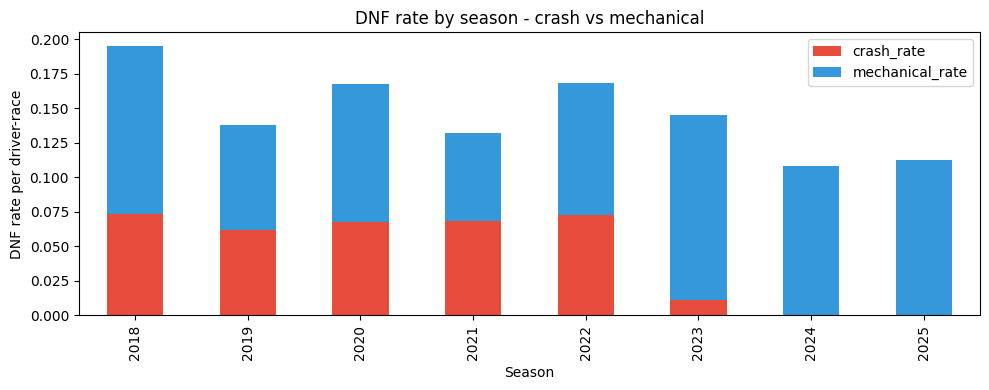

In [32]:
ax = by_season[['crash_rate', 'mechanical_rate']].plot(
    kind='bar', stacked=True, figsize=(10, 4),
    color=['#e74c3c', '#3498db'],
    title='DNF rate by season - crash vs mechanical'
)
ax.set_ylabel('DNF rate per driver-race')
ax.set_xlabel('Season')
plt.tight_layout()
plt.show()

## Why a trained DNF classifier fails - distribution shift

Trained XGBClassifier (AUC 0.507) failed because DNF rate differs significantly between train and val seasons. Rolling rate features avoid this by adapting to recent form rather than learning a global prior.

In [33]:
train = race_results[race_results['season'].isin(TRAIN_SEASONS)]
val = race_results[race_results['season'].isin(VAL_SEASONS)]

print('DNF rates by split (after lapped bug fix):')
print(f'  Train  - total: {train["dnf_flag"].mean():.3f} | crash: {train["crash_dnf_flag"].mean():.3f} | mechanical: {train["mechanical_dnf_flag"].mean():.3f}')
print(f'  Val    - total: {val["dnf_flag"].mean():.3f} | crash: {val["crash_dnf_flag"].mean():.3f} | mechanical: {val["mechanical_dnf_flag"].mean():.3f}')

DNF rates by split (after lapped bug fix):
  Train  - total: 0.157 | crash: 0.059 | mechanical: 0.098
  Val    - total: 0.109 | crash: 0.000 | mechanical: 0.109


## Constructor mechanical reliability

In [34]:
by_constructor = race_results.groupby('constructor_id')[['mechanical_dnf_flag', 'crash_dnf_flag']].mean()
by_constructor.columns = ['mechanical_rate', 'crash_rate']
by_constructor = by_constructor.sort_values('mechanical_rate', ascending=False)

print('Constructor DNF rates (all seasons):')
print(by_constructor.to_string())

Constructor DNF rates (all seasons):
                mechanical_rate  crash_rate
constructor_id                             
racing_bulls           0.145833    0.000000
williams               0.144928    0.057971
alpine                 0.140351    0.008772
kick_sauber            0.123188    0.036232
alphatauri             0.114458    0.048193
renault                0.110169    0.076271
haas                   0.109827    0.060694
toro_rosso             0.107143    0.095238
racing_point           0.105263    0.065789
aston_martin           0.101322    0.039648
force_india            0.095238    0.071429
red_bull               0.092486    0.037572
alfa_romeo             0.081731    0.052885
ferrari                0.080925    0.043353
mclaren                0.080925    0.031792
mercedes               0.057803    0.020231


## Backtest comparison - flat prior vs crash+mechanical

Compares two `dnf_prob` approaches on clean data (after lapped bug fix):
- **Flat**: `dnf_prob = 0.1` for all drivers
- **Crash+Mechanical**: `dnf_prob = rolling_crash_dnf_rate_last_5 + constructor_rolling_mechanical_dnf_rate_last_5`

Key architectural decision: dnf_prob is applied directly to expected fantasy points in `compose_drivers`, not as a position adjustment - position→points is non-linear so position adjustments don't correctly scale expected points.

In [ ]:
quali_model = load_model(QUALI_POSITION_MODEL)
finish_model = load_model(FINISH_POSITION_MODEL)

results = []

for s in VAL_SEASONS:
    schedule = fastf1.get_event_schedule(s)
    schedule = schedule[schedule['RoundNumber'] > 0]

    for round_num in schedule['RoundNumber']:
        prices_path = FANTASY_PRICES_DIR / f'{s}_{round_num:02d}.csv'
        features_path = PROCESSED_HISTORIC_FEATURES_DIR / f'{s}_{round_num:02d}.parquet'
        targets_path = PROCESSED_TARGETS_DIR / f'{s}_{round_num:02d}.parquet'

        if not (prices_path.exists() and features_path.exists() and targets_path.exists()):
            continue

        prices = pd.read_csv(prices_path)
        predictions = predict(quali_model, QUALI_POSITION_MODEL, finish_model, FINISH_POSITION_MODEL, s, round_num)

        # flat prior - same dnf_prob for everyone, no differentiation
        flat_preds = predictions.copy()
        flat_preds['dnf_prob'] = 0.1
        flat_drivers = compose_drivers(flat_preds)
        flat_constructors = compose_constructor(flat_drivers)
        flat_team = optimiser(flat_drivers, flat_constructors, prices, BUDGET_CAP)
        flat_points = get_actual_team_points(flat_team, s, round_num)

        # crash + mechanical - per-driver dnf_prob from rolling rates
        split_drivers = compose_drivers(predictions.copy())
        split_constructors = compose_constructor(split_drivers)
        split_team = optimiser(split_drivers, split_constructors, prices, BUDGET_CAP)
        split_points = get_actual_team_points(split_team, s, round_num)

        results.append({'season': s, 'round': round_num, 'flat': flat_points, 'crash_mechanical': split_points})
        print(f'{s} R{round_num:02d} - flat: {flat_points:.0f} | crash+mech: {split_points:.0f}')

df_results = pd.DataFrame(results)

2024 R01 - flat: 129 | crash+mech: 140
2024 R02 - flat: 113 | crash+mech: 137
2024 R03 - flat: 88 | crash+mech: 39
2024 R04 - flat: 146 | crash+mech: 145
2024 R05 - flat: 146 | crash+mech: 168
2024 R06 - flat: 132 | crash+mech: 127
2024 R07 - flat: 139 | crash+mech: 151
2024 R08 - flat: 156 | crash+mech: 156
2024 R09 - flat: 82 | crash+mech: 81
2024 R10 - flat: 131 | crash+mech: 131
2024 R11 - flat: 166 | crash+mech: 167
2024 R12 - flat: 168 | crash+mech: 168
2024 R13 - flat: 130 | crash+mech: 137
2024 R14 - flat: 26 | crash+mech: 99
2024 R15 - flat: 81 | crash+mech: 81
2024 R16 - flat: 147 | crash+mech: 72
2024 R17 - flat: 129 | crash+mech: 129
2024 R18 - flat: 134 | crash+mech: 124
2024 R19 - flat: 176 | crash+mech: 176
2024 R20 - flat: 118 | crash+mech: 138
2024 R21 - flat: 43 | crash+mech: 122
2024 R22 - flat: 129 | crash+mech: 86
2024 R23 - flat: 78 | crash+mech: 126
2024 R24 - flat: 45 | crash+mech: 3


In [36]:
print(f'\n{"Season":<8} {"Flat":>8} {"Crash+Mech":>12} {"Delta":>8}')
for s in VAL_SEASONS:
    sub = df_results[df_results['season'] == s]
    flat = sub['flat'].sum()
    split = sub['crash_mechanical'].sum()
    print(f'  {s}   {flat:>8.0f} {split:>12.0f} {split - flat:>+8.0f}')

flat_total = df_results['flat'].sum()
split_total = df_results['crash_mechanical'].sum()
print(f'  {"Total":<6} {flat_total:>8.0f} {split_total:>12.0f} {split_total - flat_total:>+8.0f}')


Season       Flat   Crash+Mech    Delta
  2024       2832         2903      +71
  Total      2832         2903      +71


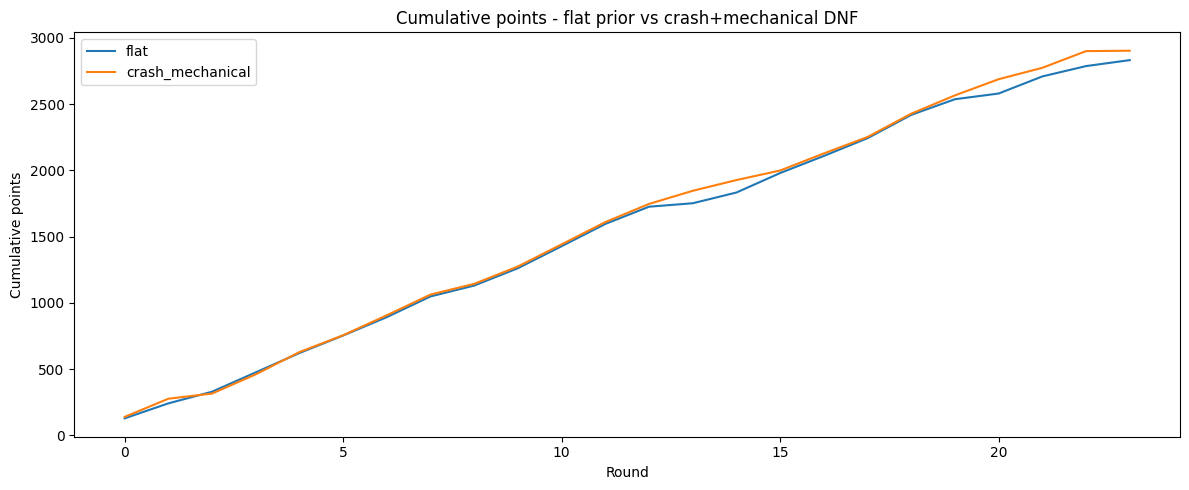

In [37]:
df_results[['flat', 'crash_mechanical']].cumsum().plot(
    figsize=(12, 5),
    title='Cumulative points - flat prior vs crash+mechanical DNF'
)
plt.xlabel('Round')
plt.ylabel('Cumulative points')
plt.tight_layout()
plt.show()